In [1]:
%load_ext autoreload
%autoreload 2

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+3001=3001. 
  warnings.warn(
/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/lib/python3.9/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+301=301. 
  warnings.warn(


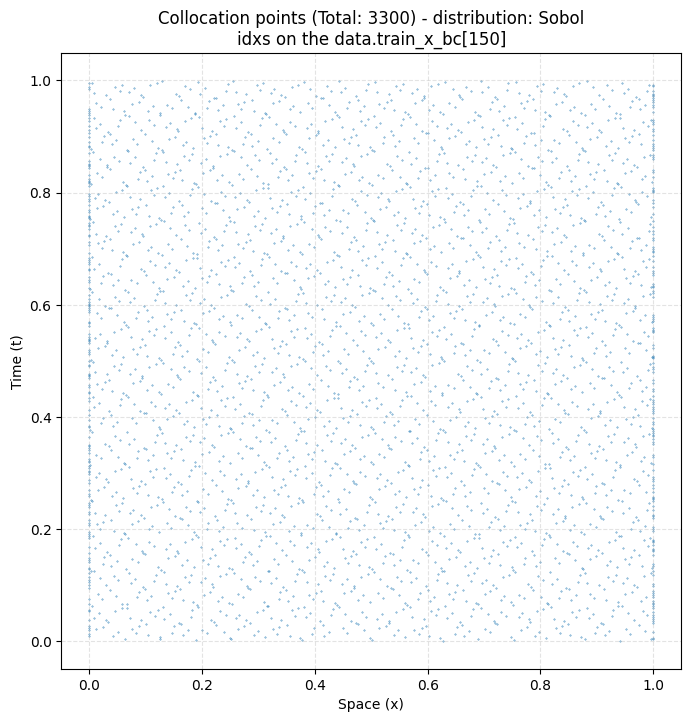

Compiling model...
'compile' took 0.002050 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.51e+08, 6.53e-01, 8.36e-11, 1.99e+03]    [2.51e+08, 6.53e-01, 8.36e-11, 1.99e+03]    []  
50        [1.63e+06, 1.91e-02, 1.40e-10, 3.97e+01]    [1.63e+06, 1.91e-02, 1.40e-10, 3.97e+01]    []  
100       [6.70e+05, 1.02e-02, 2.15e-10, 1.78e+01]    [6.70e+05, 1.02e-02, 2.15e-10, 1.78e+01]    []  
150       [3.70e+05, 6.74e-03, 3.15e-10, 1.05e+01]    [3.70e+05, 6.74e-03, 3.15e-10, 1.05e+01]    []  
200       [2.38e+05, 4.88e-03, 4.21e-10, 7.07e+00]    [2.38e+05, 4.88e-03, 4.21e-10, 7.07e+00]    []  

Best model at step 200:
  train loss: 2.38e+05
  test loss: 2.38e+05
  test metric: []

'train' took 23.704538 s

Saving loss history to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/loss.dat ...
Saving training data to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/train.dat ...

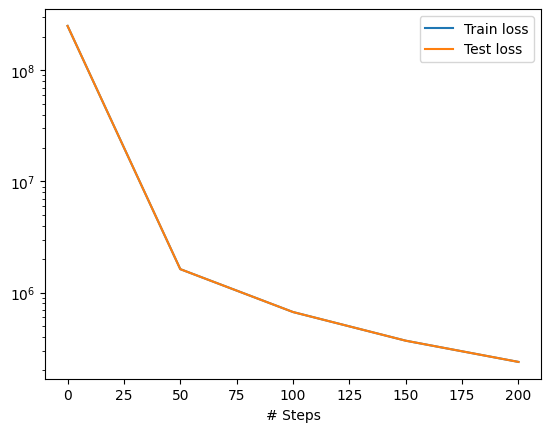

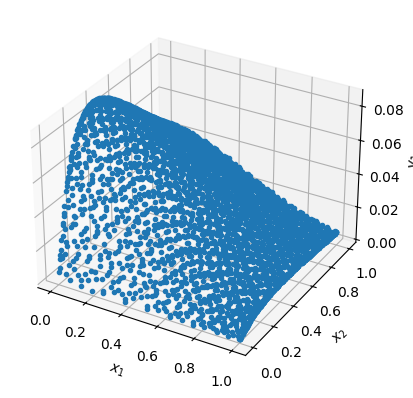

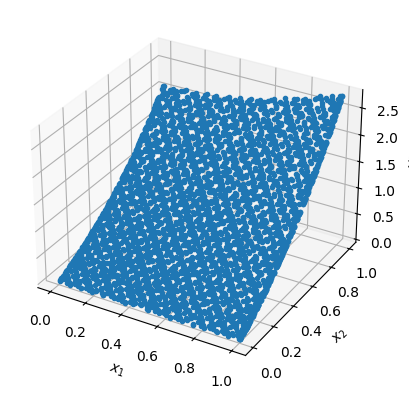

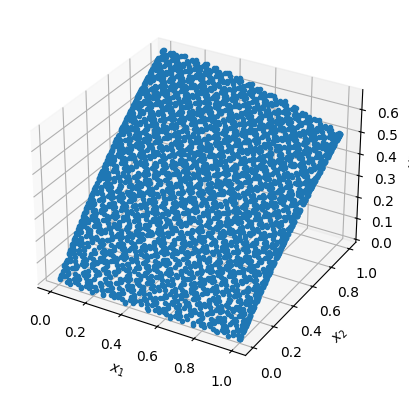

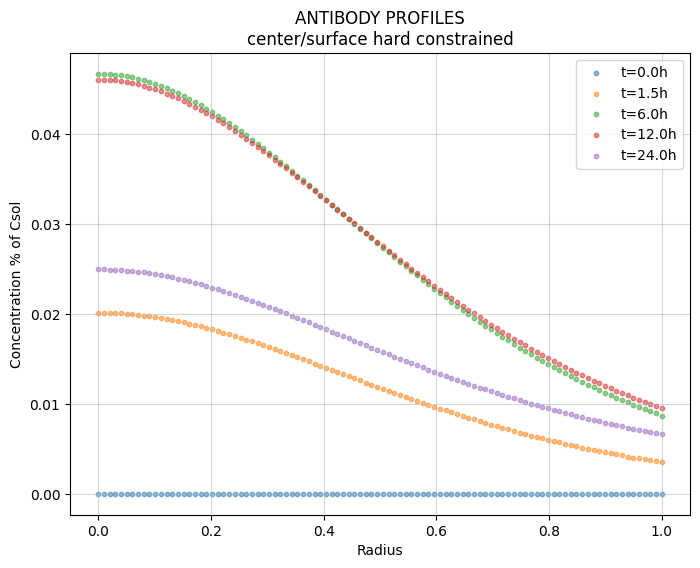

In [76]:
import deepxde as dde
from spheroid_dde.utils.context import DimLessModel, Antibody, CharacteristicUnits, PhaseSpecification, phi_antibody, phi_liposomes
from spheroid_dde.pdes.antibody import binding_antibody_system_of_pdes, robin_surface_binding_antibody, hard_constraint_center_boundary_transform_binding, hard_constraint_initial_transform_binding
from spheroid_dde.pdes.liposomes import liposome_pde, robin_operator_liposome, hard_constraint_center_boundary_transform_liposome, hard_constraint_initial_transform_liposome 
from spheroid_dde.utils.boundary_filters import initial_time_filter, center_filter, surface_filter
from spheroid_dde.utils.plotting import scatter_collocation_points
from spheroid_dde.utils.plotting import plot_2d_antibody, plot_2d_liposome


# set pytorch as the default backend.
dde.backend.set_default_backend("pytorch")

### 1. Define problem objects.
transtuzumab = Antibody(D=8.38, Koff=4e-3, Kd=6.76, Kint=1.4e-5, Rt=1060, phi=lambda r: 0.44 * r**3.2 + 0.56)

units = CharacteristicUnits(C0=60, R=200)
uptake_spec = PhaseSpecification('uptake', tau=24*3600, Cext=60, P=2.5e-4)
uptake_dimless = DimLessModel(transtuzumab, units, uptake_spec)


### 2. Spatiotemporal geometry.
geometry = dde.geometry.Interval(0, 1) # 1D spatial domain (normalized radius)
timedomain = dde.geometry.TimeDomain(0, 1) # temporal domain (normalized time)
spacetime = dde.geometry.GeometryXTime(geometry, timedomain) # spatiotemporal domain



### 3. Define boundary and initial conditions.
# ICs
ic_interstitial = dde.icbc.IC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_initial=initial_time_filter,
    component=0
)
ic_bound = dde.icbc.IC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_initial=initial_time_filter,
    component=1
)
ic_internalized = dde.icbc.IC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_initial=initial_time_filter,
    component=2
)

# BCs.
center_neumann = dde.icbc.NeumannBC(
    geom=spacetime,
    func=lambda x: 0.0,
    on_boundary=center_filter,
    component=0
)
surface_robin = dde.icbc.OperatorBC(
    geom=spacetime,
    func=robin_surface_binding_antibody,
    on_boundary=surface_filter
)
######################################################################################################################################################

## Liposomes...
surface_liposome = dde.icbc.OperatorBC(
    geom=spacetime,
    func=robin_operator_liposome,
    on_boundary=surface_filter
)
ic_bcs_non_specific_antibody = [ic_interstitial, center_neumann, surface_liposome] 
loss_weights_non_specific = [1.0, 1.0, 1.0, 100.0]

######################################################################################################################################################

## BINDING ANTIBODIES...
bc_surface_antibody = dde.icbc.OperatorBC(
    geom=spacetime,
    func=robin_surface_binding_antibody,
    on_boundary=surface_filter
)
ic_bcs_antibody = [bc_surface_antibody]
loss_weights_binding_antibody = [1.0, 1.0, 1.0, 10.0]

######################################################################################################################################################
dist = {"a": 'LHS', 'b': 'Halton', 'c': 'Hammersley', 'd': 'Sobol'}

data = dde.data.TimePDE(
    geometryxtime=spacetime,
    pde=binding_antibody_system_of_pdes,
    ic_bcs=ic_bcs_antibody,
    num_domain=3000,
    num_boundary=300,
    num_initial=0,
    train_distribution=dist['d']
)
scatter_collocation_points(data)

layer_size = [2] + [256] * 4 + [3]
net = dde.nn.FNN(layer_size, "tanh", "Glorot normal")
net.apply_feature_transform(hard_constraint_center_boundary_transform_binding) # Enforce symmetry at r=0 and zero initial condition at t=0 through input transformation
net.apply_output_transform(hard_constraint_initial_transform_binding) # Scale output by time to enforce zero initial condition at t=0


model = dde.Model(data, net)
model.compile("adam", lr=1e-4, loss_weights=loss_weights_binding_antibody)
adam_losshistory, adam_train_state = model.train(iterations=200, display_every=50)
dde.saveplot(adam_losshistory, adam_train_state, issave=True, isplot=True)
adam_model = model

# model.compile(optimizer='L-BFGS')
# lbfgs_losshistory, lbfgs_train_state = model.train()
# dde.saveplot(lbfgs_losshistory, lbfgs_train_state, issave=True, isplot=True)
# lbfgs_model = model



lip_save_path = 'results/liposomes'
ab_save_path = 'results/liposomes'
plot_2d_antibody(adam_model, time_list=[0.0, 1/16, 4/16, 8/16, 1.0], C_scale=1, r_scale=1, t_scale=24, save_path=None, lambda_phi=phi_antibody)